In [44]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

Para el modelo predictivo hay que tener las mismas features, así que hay que revisar los notebooks, donde se trataron los datos, también hay que tener en cuenta las features que usamos en un anterior proyecto apra darle más info al modelo, están en obsidian explicadas

Hay que quitar lo de close_time, open_time, tienen directamente usarlas como features, al calcular los retornos hay que usar shift(1) correctaemtne para solo usar los datos anteriores al target.

Los features bases para cada dataset son los siguientes, hay que quitarlos dentro del tratamiento de los bars correspondientes dentro de los notebooks donde se limpiaron los datos. Las features son las siguientes: 

['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'return']


In [45]:
class CleanData:
    def __init__(self):
        pass

    def robust_to_datetime(self, series):
        """Convierte series a datetime manejando múltiples formatos."""
        if np.issubdtype(series.dtype, np.datetime64):
            return series
        
        s = series.copy()
        as_str = s.dropna().astype(str)
        is_all_digits = as_str.str.match(r'^\d+$').mean()
        
        if is_all_digits > 0.5:
            sample_num = as_str.sample(min(100, len(as_str))).astype(float)
            median_sample = sample_num.median()
            print(f"  Mediana muestra: {median_sample}")
            
            if median_sample > 1e12:
                print("  -> Epoch en MILLISEGUNDOS")
                out = pd.to_datetime(s.astype(float), unit='ms', errors='coerce')
            elif median_sample > 1e9:
                print("  -> Epoch en SEGUNDOS")
                out = pd.to_datetime(s.astype(float), unit='s', errors='coerce')
            else:
                out = pd.to_datetime(s, errors='coerce')
            return out
        else:
            out = pd.to_datetime(s, errors='coerce', utc=False)
            return out


    def convert_datetime_columns(self, data: pd.DataFrame) -> pd.DataFrame:
        """Convierte columnas de tiempo a datetime."""
        print("Convirtiendo fechas...")
        
        if 'open_time' in data.columns:
            data['open_time'] = self.robust_to_datetime(data['open_time'])
        if 'close_time' in data.columns:
            data['close_time'] = self.robust_to_datetime(data['close_time'])
        
        data = data.dropna(subset=['open_time'])
        print(f"  ✓ Filas válidas: {len(data)}")
        
        return data
    
    def normalize_structure(self, df: pd.DataFrame) -> pd.DataFrame:
        """Asegura columnas necesarias."""
        required_cols = ['open', 'high', 'low', 'close', 'volume']
        for col in required_cols:
            if col not in df.columns:
                raise ValueError(f"Falta columna requerida: {col}")
        return df

In [46]:
class BitcoinBarsAnalizer:
    def __init__(self, time_bars_path, volume_bars_path, dollar_bars_path):
        self.time_bars = pd.read_csv(time_bars_path)
        self.volume_bars = pd.read_csv(volume_bars_path)
        self.dollar_bars = pd.read_csv(dollar_bars_path)
        self.clean_data = CleanData()
        
        # limpiar y normalizar
        for df_name in ['time_bars', 'volume_bars', 'dollar_bars']:
            df = getattr(self, df_name)
            df = self.clean_data.convert_datetime_columns(df)
            df = self.clean_data.normalize_structure(df)
            setattr(self, df_name, df)
        
        self.results = {}

    # ------------------------------------------------------------
    #   TARGET BASADO EN RETORNOS FUTUROS ACUMULADOS
    # ------------------------------------------------------------
    def define_future_return_target(self, df: pd.DataFrame, horizon=5, threshold=None) -> pd.Series:
        """
        Define un target ternario basado en el retorno acumulado a futuro (H bars).
        +1 = subida sostenida
        -1 = bajada sostenida
        0  = sin dirección clara
        """
        future_return = (df['close'].shift(-horizon) - df['close']) / df['close']

        if threshold is None:
            threshold = np.percentile(np.abs(future_return.dropna()), 75)

        df['target'] = np.where(future_return > threshold, 1,
                        np.where(future_return < -threshold, -1, 0))

        print(f"  ✓ Target generado con H={horizon}, threshold={threshold:.6f}")
        print(df['target'].value_counts(normalize=True).round(4).rename('Proporción por clase'))
        
        return df['target']

    # ------------------------------------------------------------
    #   CREACIÓN DE FEATURES
    # ------------------------------------------------------------
    def create_features(self, df: pd.DataFrame, horizon=5):
        df = df.copy()
        
        # returns 
        df['returns'] = df['close'].pct_change()
        df['log_returns'] = np.log(df['close'] / df['close'].shift(1))
        
        # range volatility
        df['range'] = (df['high'] - df['low']) / df['open']
        df['range_pct'] = (df['high'] - df['low']) / df['close']
        
        # body vs shadow
        df['body'] = abs(df['close'] - df['open'])
        df['upper_shadow'] = df['high'] - df[['open', 'close']].max(axis=1)
        df['lower_shadow'] = df[['open', 'close']].min(axis=1) - df['low']
        
        # momentum features
        df['price_momentum'] = df['close'] - df['close'].shift(5)
        df['volume_momentum'] = df['close'].rolling(20).mean()
        
        # moving averages
        df['sma_5'] = df['close'].rolling(5).mean()
        df['sma_20'] = df['close'].rolling(20).mean()
        df['price_vs_sma5'] = (df['close'] - df['sma_5']) / df['sma_5']
        df['price_vs_sma20'] = (df['close'] - df['sma_20']) / df['sma_20']
        
        # volatility 
        df['volatility_5'] = df['returns'].rolling(5).std()
        df['volatility_20'] = df['returns'].rolling(20).std()
        
        # volume features
        df['volume_sma_5'] = df['volume'].rolling(5).mean()
        df['volume_ratio'] = df['volume'] / df['volume_sma_5']
        
        # nuevo target acumulado
        df['target'] = self.define_future_return_target(df, horizon=horizon)
        
        return df

    # ------------------------------------------------------------
    #   PREPARACIÓN DE DATOS
    # ------------------------------------------------------------
    def prepare_data(self, df: pd.DataFrame, horizon=5):
        df = self.create_features(df, horizon)
        df = df.dropna()
        
        feature_cols = [
            'returns', 'log_returns', 'range', 'range_pct',
            'body', 'upper_shadow', 'lower_shadow',
            'price_momentum', 'volume_momentum',
            'price_vs_sma5', 'price_vs_sma20',
            'volatility_5', 'volatility_20',
            'volume_ratio'
        ]
        
        X = df[feature_cols]
        y = df['target']
        return X, y, df

    # ------------------------------------------------------------
    #   ENTRENAMIENTO Y EVALUACIÓN
    # ------------------------------------------------------------
    def train_evaluate_model(self, X, y, bar_type):
        tscv = TimeSeriesSplit(n_splits=5)
        
        accuracies, f1_scores, importances = [], [], []
        
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            model = RandomForestClassifier(
                n_estimators=100,
                max_depth=10,
                min_samples_split=50,
                random_state=42,
                n_jobs=-1
            )
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            accuracies.append(accuracy_score(y_test, y_pred))
            f1_scores.append(f1_score(y_test, y_pred, average='macro'))
            importances.append(model.feature_importances_)
        
        self.results[bar_type] = {
            'accuracy_mean': np.mean(accuracies),
            'accuracy_std': np.std(accuracies),
            'f1_mean': np.mean(f1_scores),
            'f1_std': np.std(f1_scores),
            'feature_importance': np.mean(importances, axis=0),
            'feature_names': X.columns.tolist()
        }
        
        print(f"\n=== {bar_type.upper()} BARS ===")
        print(f"Accuracy: {np.mean(accuracies):.4f} ±{np.std(accuracies):.4f}")
        print(f"F1-Score: {np.mean(f1_scores):.4f} ±{np.std(f1_scores):.4f}")
        
        return model

    # ------------------------------------------------------------
    #   ANÁLISIS COMPLETO
    # ------------------------------------------------------------
    def run_full_analysis(self, horizon=5):
        print(f"Iniciando análisis comparativo con H={horizon}...")
        
        for name, df in [('time', self.time_bars), 
                         ('volume', self.volume_bars), 
                         ('dollar', self.dollar_bars)]:
            X, y, _ = self.prepare_data(df, horizon)
            self.train_evaluate_model(X, y, name)
        
        self.plot_comparison()
        return self.results

    # ------------------------------------------------------------
    #   VISUALIZACIÓN
    # ------------------------------------------------------------
    def plot_comparison(self):
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        bar_types = list(self.results.keys())
        accuracies = [self.results[b]['accuracy_mean'] for b in bar_types]
        f1_scores = [self.results[b]['f1_mean'] for b in bar_types]
        
        x = np.arange(len(bar_types))
        width = 0.35
        
        # Scores comparativos
        axes[0, 0].bar(x - width/2, accuracies, width, label='Accuracy', alpha=0.8)
        axes[0, 0].bar(x + width/2, f1_scores, width, label='F1-Score', alpha=0.8)
        axes[0, 0].set_xticks(x)
        axes[0, 0].set_xticklabels(bar_types)
        axes[0, 0].set_title('Comparación de Rendimiento')
        axes[0, 0].legend()
        axes[0, 0].grid(axis='y', alpha=0.3)
        
        # Feature importances
        for idx, bar_type in enumerate(bar_types):
            fi = self.results[bar_type]['feature_importance']
            fn = self.results[bar_type]['feature_names']
            top_idx = np.argsort(fi)[-10:]
            ax = axes.flat[idx+1]
            ax.barh(range(10), fi[top_idx])
            ax.set_yticks(range(10))
            ax.set_yticklabels([fn[i] for i in top_idx])
            ax.set_title(f'Top Features - {bar_type.capitalize()} Bars')
            ax.grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('bars_comparison_horizon.png', dpi=300, bbox_inches='tight')
        plt.show()

Convirtiendo fechas...
  ✓ Filas válidas: 43138
Convirtiendo fechas...
  ✓ Filas válidas: 5286
Convirtiendo fechas...
  ✓ Filas válidas: 29397
Iniciando análisis comparativo con H=5...
  ✓ Target generado con H=5, threshold=0.001471
target
 0    0.7500
-1    0.1257
 1    0.1243
Name: Proporción por clase, dtype: float64

=== TIME BARS ===
Accuracy: 0.7504 ±0.0603
F1-Score: 0.3128 ±0.0078
  ✓ Target generado con H=5, threshold=0.005028
target
 0    0.7503
-1    0.1281
 1    0.1216
Name: Proporción por clase, dtype: float64

=== VOLUME BARS ===
Accuracy: 0.6958 ±0.0813
F1-Score: 0.2887 ±0.0054
  ✓ Target generado con H=5, threshold=0.001941
target
 0    0.7500
-1    0.1268
 1    0.1232
Name: Proporción por clase, dtype: float64

=== DOLLAR BARS ===
Accuracy: 0.7420 ±0.0323
F1-Score: 0.2976 ±0.0101


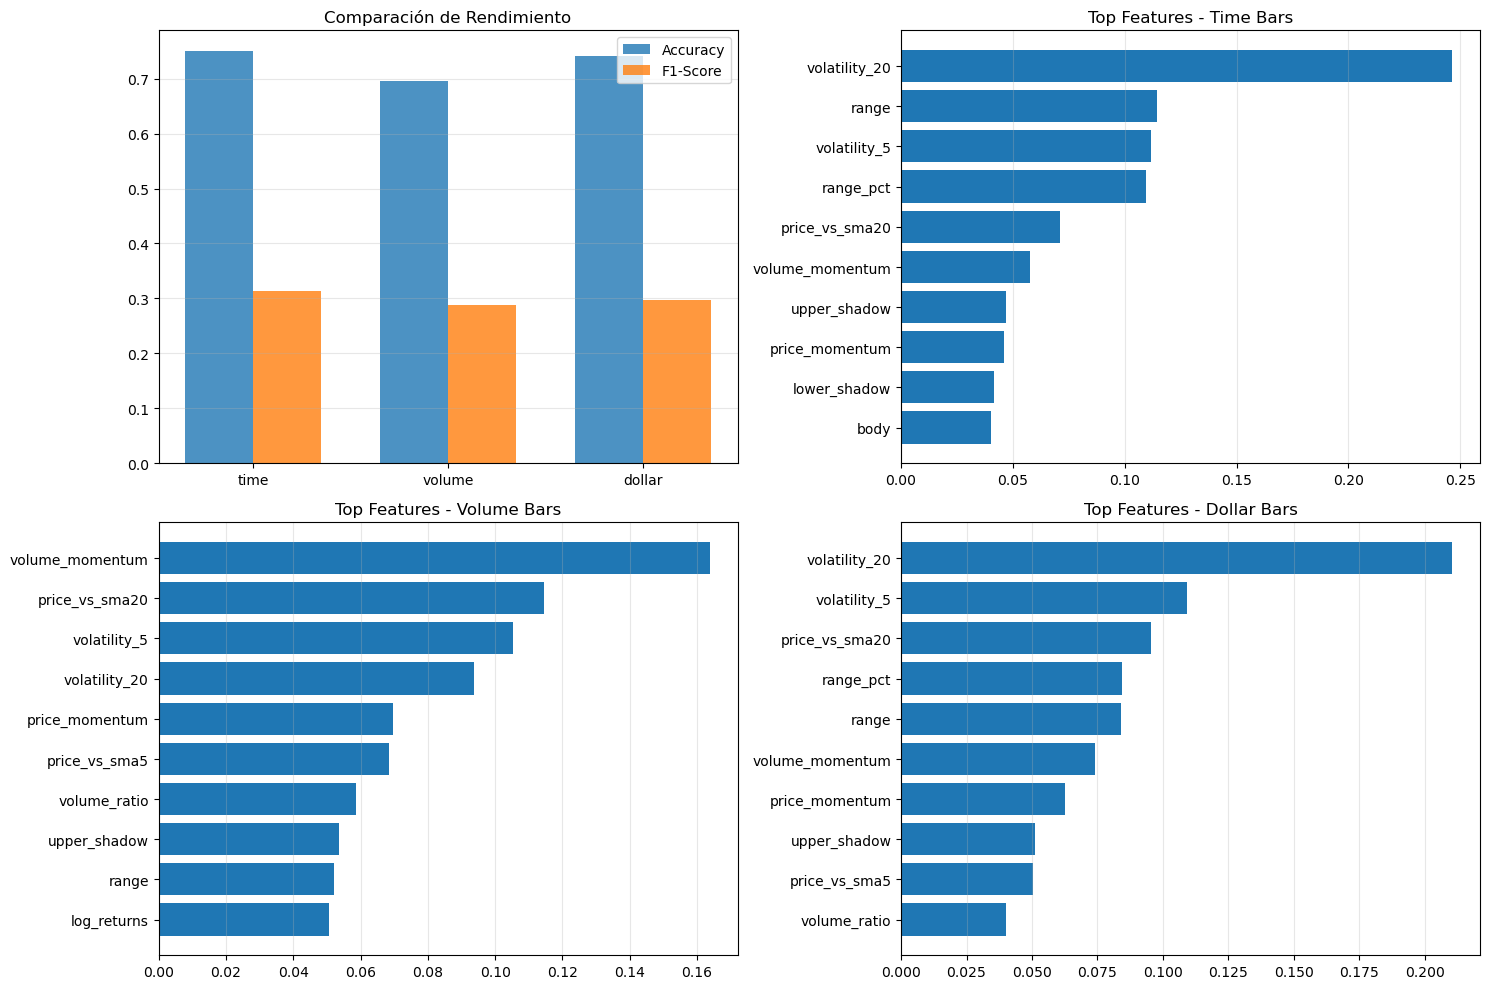

In [47]:
path = '../data/processed/'

analyzer = BitcoinBarsAnalizer(
    time_bars_path= f'{path}/BTCUSDT_1m_2024-12-01_to_2025-01-01_cleaned_robust.csv',
    volume_bars_path= f'{path}/BTCUSDT_1m_2024-12-01_to_2025-01-volume.csv',
    dollar_bars_path= f'{path}/BTCUSDT_1m_2024-12-01_to_2025-01-01_dollar_bars_dyn.csv'
)

results = analyzer.run_full_analysis()


